# Práctica combinada: Ingeniería de Características + Naive Bayes
## Predicción de duración de carrera en la NBA


## Introducción general

Este notebook combina, en un solo recorrido, las dos prácticas de mañana:

1. **Ingeniería de características** — a partir de estadísticas de jugadores novatos de la NBA, seleccionamos, transformamos y extraemos las características más útiles para predecir si un jugador durará **5 años o más** en la liga.
2. **Naive Bayes** — usamos esas características para entrenar un modelo de clasificación binaria, evaluarlo con métricas estándar, y comparar variantes del algoritmo.

Además de reproducir el contenido de los dos laboratorios originales (`Perform feature engineering` y `Build a Naive Bayes model`), este notebook agrega:

- **Teoría extra**: qué es la ingeniería de características y sus 3 etapas; el teorema de Bayes y las variantes de Naive Bayes (Gaussian, Multinomial, Bernoulli, Categorical).
- **Visualizaciones adicionales**: distribución de clases, correlaciones, comparación de features antes/después de la extracción, curva ROC.
- **Comparación de modelos**: `GaussianNB` (features continuas) vs. `BernoulliNB` (features binarizadas), para mostrar por qué el supuesto del algoritmo importa.

Las dos partes están armadas para poder mostrarse **de forma independiente** (cada una carga su propio archivo `.csv`), aunque conceptualmente la Parte 2 usa el resultado de la Parte 1.


---
# PARTE 1 · Ingeniería de características
---

## ¿Qué es la ingeniería de características? *(contenido extra)*

La **ingeniería de características** (*feature engineering*) es el proceso de usar el conocimiento del dominio y los datos disponibles para crear, modificar o descartar variables (*features*) que le den a un modelo la mejor información posible para predecir el objetivo.

Se suele dividir en tres etapas, que vamos a recorrer más abajo:

| Etapa | ¿Qué hace? | Ejemplo en este dataset |
|---|---|---|
| **Selección** | Elegir qué columnas conservar y cuáles descartar | Sacar `name`, quedarnos con estadísticas de rendimiento |
| **Transformación** | Modificar el formato de una variable (p. ej. codificar categóricas, escalar) | No aplica aquí porque no quedan columnas categóricas |
| **Extracción** | Combinar columnas existentes para crear nuevas variables más informativas | `total_points`, `efficiency` |

**¿Por qué importa?** Un modelo solo puede aprender de la información que le damos. Buenas features pueden mejorar mucho el rendimiento predictivo incluso sin cambiar el algoritmo, mientras que features redundantes o irrelevantes agregan ruido y aumentan el riesgo de sobreajuste.


## Paso 1: Importaciones

In [1]:
# Importar librerías.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

El conjunto de datos es un archivo .csv llamado `nba-players.csv`, con registros de rendimiento de jugadores novatos de la NBA.

In [2]:
# Cargar los datos.

data = pd.read_csv("nba-players.csv", index_col=0)

## Paso 2: Exploración de datos

In [3]:
# Mostrar las primeras 10 filas.

data.head(10)

,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1
5,Tony Bennett,75,11.4,3.7,1.5,3.5,42.3,0.3,1.1,32.5,...,0.5,73.2,0.2,0.7,0.8,1.8,0.4,0.0,0.7,0
6,Don MacLean,62,10.9,6.6,2.5,5.8,43.5,0.0,0.1,50.0,...,1.8,81.1,0.5,1.4,2.0,0.6,0.2,0.1,0.7,1
7,Tracy Murray,48,10.3,5.7,2.3,5.4,41.5,0.4,1.5,30.0,...,0.8,87.5,0.8,0.9,1.7,0.2,0.2,0.1,0.7,1
8,Duane Cooper,65,9.9,2.4,1.0,2.4,39.2,0.1,0.5,23.3,...,0.5,71.4,0.2,0.6,0.8,2.3,0.3,0.0,1.1,0
9,Dave Johnson,42,8.5,3.7,1.4,3.5,38.3,0.1,0.3,21.4,...,1.4,67.8,0.4,0.7,1.1,0.3,0.2,0.0,0.7,0


In [4]:
# Número de filas y columnas.

data.shape

(1340, 21)

**Observación:** hay 1,340 filas y 21 columnas.

In [5]:
# Nombres de todas las columnas.

data.columns

Index(['name', 'gp', 'min', 'pts', 'fgm', 'fga', 'fg', '3p_made', '3pa', '3p',
       'ftm', 'fta', 'ft', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov',
       'target_5yrs'],
      dtype='str')

|Columna|Descripción|
|:---|:-------|
|`name`|Nombre del jugador|
|`gp`|Partidos jugados|
|`min`|Minutos jugados por partido|
|`pts`|Puntos promedio por partido|
|`fgm` / `fga` / `fg`|Tiros de campo anotados / intentados / % anotado|
|`3p_made` / `3pa` / `3p`|Triples anotados / intentados / % anotado|
|`ftm` / `fta` / `ft`|Tiros libres anotados / intentados / % anotado|
|`oreb` / `dreb` / `reb`|Rebotes ofensivos / defensivos / totales|
|`ast`|Asistencias promedio|
|`stl`|Robos promedio|
|`blk`|Bloqueos promedio|
|`tov`|Pérdidas promedio|
|`target_5yrs`|1 si la carrera duró 5+ años, 0 en caso contrario|


In [6]:
# Resumen del DataFrame: tipos de datos, nulos, etc.

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         1340 non-null   str    
 1   gp           1340 non-null   int64  
 2   min          1340 non-null   float64
 3   pts          1340 non-null   float64
 4   fgm          1340 non-null   float64
 5   fga          1340 non-null   float64
 6   fg           1340 non-null   float64
 7   3p_made      1340 non-null   float64
 8   3pa          1340 non-null   float64
 9   3p           1340 non-null   float64
 10  ftm          1340 non-null   float64
 11  fta          1340 non-null   float64
 12  ft           1340 non-null   float64
 13  oreb         1340 non-null   float64
 14  dreb         1340 non-null   float64
 15  reb          1340 non-null   float64
 16  ast          1340 non-null   float64
 17  stl          1340 non-null   float64
 18  blk          1340 non-null   float64
 19  tov          1340

**Observación:** `name` es categórica (texto); el resto de las columnas son numéricas.

### Visualización extra: distribuciones de features clave

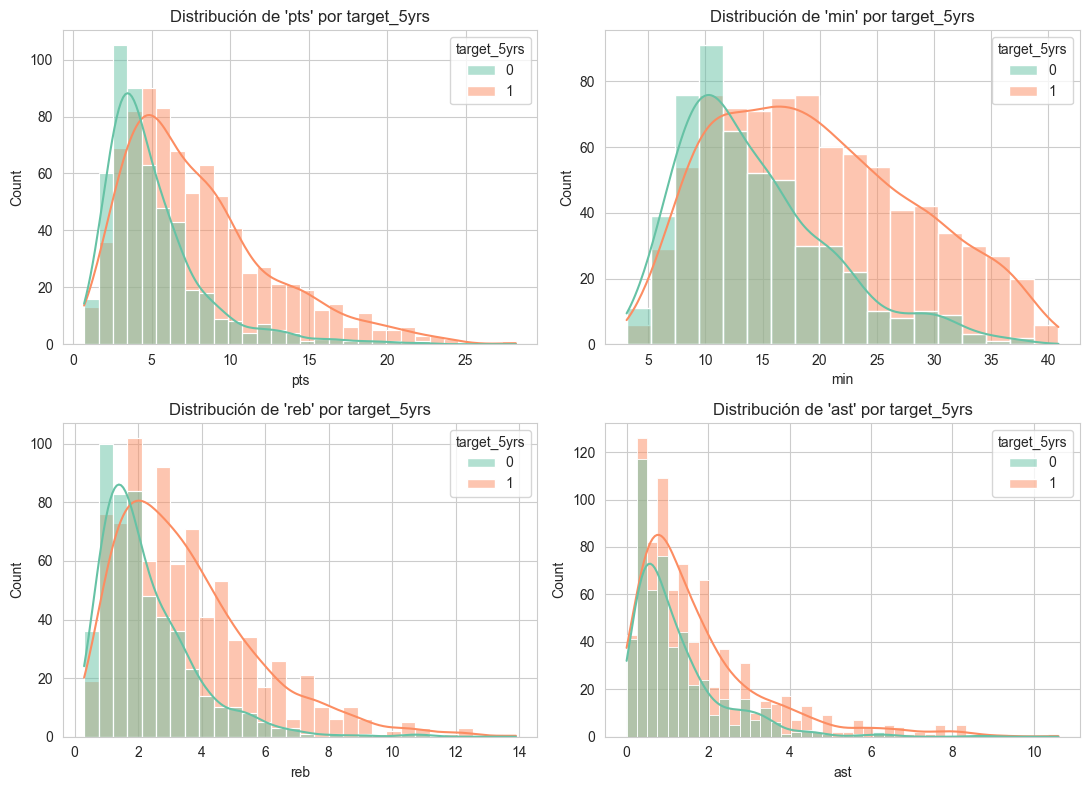

In [7]:
# Distribución de algunas variables numéricas clave, separadas por la clase objetivo.

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features_to_plot = ["pts", "min", "reb", "ast"]

for ax, feature in zip(axes.flat, features_to_plot):
    sns.histplot(data=data, x=feature, hue="target_5yrs", kde=True, ax=ax, palette="Set2")
    ax.set_title(f"Distribución de '{feature}' por target_5yrs")

plt.tight_layout()
plt.show()

Ya en estas distribuciones se nota una tendencia: los jugadores que duran 5+ años en la liga (`target_5yrs = 1`) tienden a jugar más minutos y anotar más puntos por partido.

### Verificar valores faltantes

In [8]:
# Cantidad de valores faltantes por columna.

data.isna().sum()

name           0
gp             0
min            0
pts            0
fgm            0
fga            0
fg             0
3p_made        0
3pa            0
3p             0
ftm            0
fta            0
ft             0
oreb           0
dreb           0
reb            0
ast            0
stl            0
blk            0
tov            0
target_5yrs    0
dtype: int64

**Observación:** ninguna columna tiene valores faltantes. Aun así, es buena práctica visualizarlo — así se vería un mapa de valores faltantes si los hubiera (útil como técnica reutilizable en otros datasets):

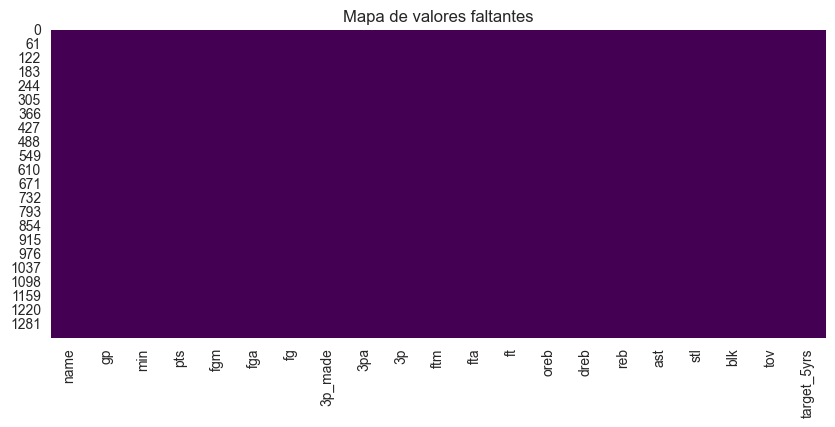

In [9]:
# Mapa de valores faltantes (extra). En este dataset debería salir completamente vacío.

plt.figure(figsize=(10, 4))
sns.heatmap(data.isna(), cbar=False, cmap="viridis")
plt.title("Mapa de valores faltantes")
plt.show()

## Paso 3: Pruebas estadísticas

In [10]:
# Porcentaje de valores en cada clase de la columna objetivo.

data["target_5yrs"].value_counts(normalize=True) * 100

target_5yrs
1    62.014925
0    37.985075
Name: proportion, dtype: float64

C:\Users\emipa\AppData\Local\Temp\ipykernel_12972\284915042.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x="target_5yrs", palette="Set2")
C:\Users\emipa\AppData\Local\Temp\ipykernel_12972\284915042.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Menos de 5 años (0)", "5 años o más (1)"])


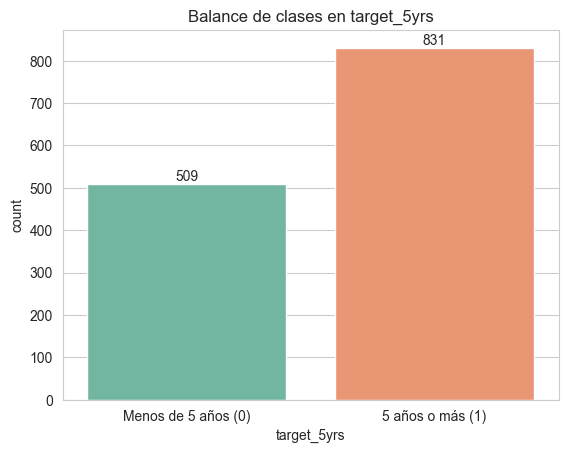

In [11]:
# Visualización extra del balance de clases.

ax = sns.countplot(data=data, x="target_5yrs", palette="Set2")
ax.set_xticklabels(["Menos de 5 años (0)", "5 años o más (1)"])
ax.set_title("Balance de clases en target_5yrs")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

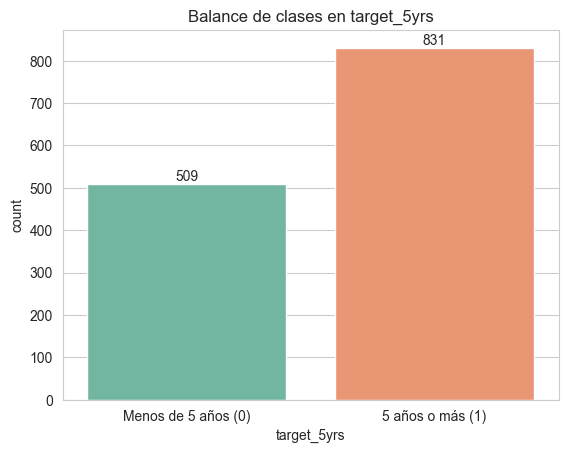

In [12]:
ax = sns.countplot(data=data, x="target_5yrs", hue="target_5yrs", palette="Set2", legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Menos de 5 años (0)", "5 años o más (1)"])
ax.set_title("Balance de clases en target_5yrs")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

Cambios:

- hue="target_5yrs", legend=False — reemplaza el uso deprecado de palette sin hue.
- ax.set_xticks([0, 1]) antes de set_xticklabels(...) — fija las posiciones de los ticks explícitamente para que las etiquetas no se desalineen.

**Observación:** ~62% de los jugadores pertenecen a la clase 1 y ~38% a la clase 0. No es un split perfecto 50-50, pero tampoco está muy desbalanceado (recién sería preocupante si una clase superara ~90%).

### Correlación con el objetivo *(prueba estadística extra)*

Además de mirar el balance de clases, podemos cuantificar qué tan relacionada está cada variable numérica con `target_5yrs` usando el coeficiente de correlación de Pearson. Esto nos da una base **cuantitativa** (no solo intuición) para la selección de características que hacemos más abajo.

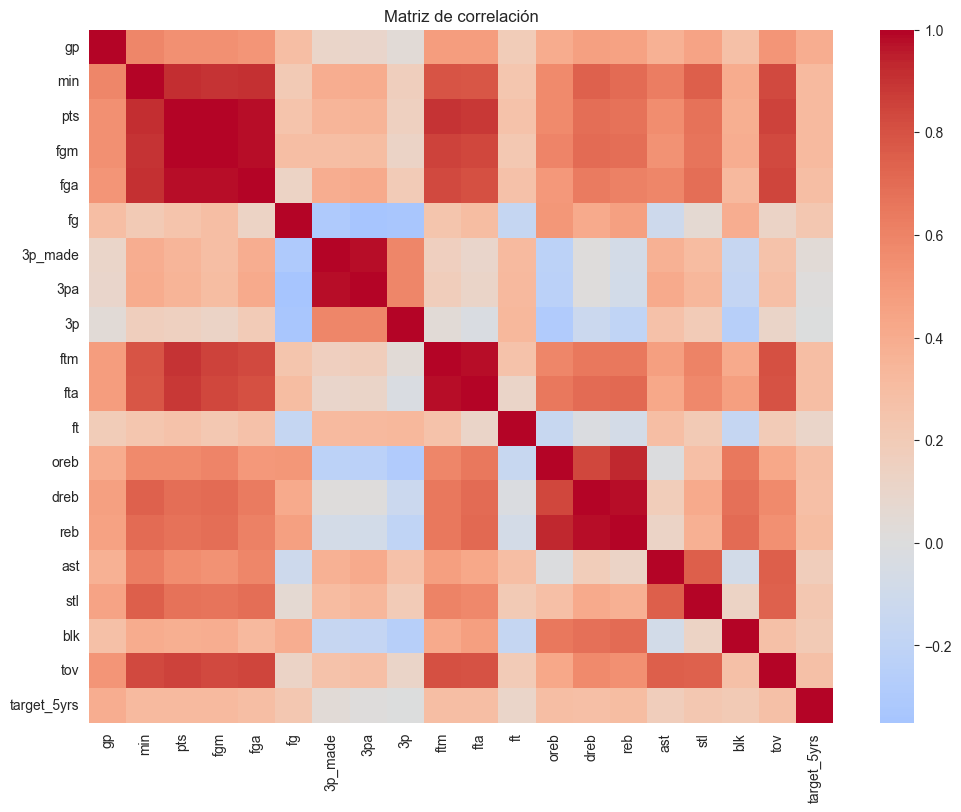

In [13]:
# Matriz de correlación de todas las variables numéricas.

corr = data.drop(columns=["name"]).corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

In [14]:
# Correlación de cada variable con la columna objetivo, ordenada de mayor a menor.

corr["target_5yrs"].sort_values(ascending=False)

target_5yrs    1.000000
gp             0.396833
min            0.317805
fgm            0.317594
pts            0.315981
reb            0.299406
ftm            0.296841
fta            0.296089
oreb           0.293307
fga            0.292660
dreb           0.284677
tov            0.272348
stl            0.229811
fg             0.227134
blk            0.210114
ast            0.175353
ft             0.106706
3p_made        0.036619
3pa            0.018110
3p            -0.000004
Name: target_5yrs, dtype: float64

**Observación:** las variables con mayor correlación con `target_5yrs` son estadísticas de volumen de juego y anotación (`pts`, `min`, `gp`, `fgm`, `fga`...), lo cual respalda con datos la selección de características que se hace a continuación de forma manual/conceptual.

## Paso 4: Resultados y evaluación

### Selección de características

**¿Qué columnas conviene seleccionar y cuáles evitar?**

- Se evita `name`: el nombre de un jugador no predice nada (y sería cuestionable éticamente usarlo).
- `gp` (partidos jugados) por sí sola no es tan informativa como los puntos obtenidos, pero combinada con `pts` sirve para *extraer* el total de puntos anotados más adelante.
- De los tres campos de tiros de campo, el **porcentaje** (`fg`) resume mejor el rendimiento que los conteos absolutos (`fgm`, `fga`). Mismo criterio para triples (`3p`) y libres (`ft`).
- `reb` ya combina `oreb` + `dreb`, así que alcanza con el total.
- `ast`, `stl`, `blk`, `tov` aportan información de rendimiento en cancha.

Columnas seleccionadas: `gp`, `min`, `pts`, `fg`, `3p`, `ft`, `reb`, `ast`, `stl`, `blk`, `tov`, `target_5yrs`.

In [16]:
# Seleccionar columnas y guardar en `selected_data`.

selected_data = data[["gp", "min", "pts", "fg", "3p", "ft", "reb", "ast", "stl", "blk", "tov", "target_5yrs"]]

selected_data.head()

,gp,min,pts,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs
0,36,27.4,7.4,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0
1,35,26.9,7.2,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0
2,74,15.3,5.2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0
3,58,11.6,5.7,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1
4,48,11.5,4.5,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1


### Transformación de características

**¿Hace falta transformar alguna variable?** No: la única columna categórica (`name`) ya fue descartada, así que todas las columnas seleccionadas ya son numéricas. Si hubiera quedado alguna variable categórica, habría que codificarla (por ejemplo con *one-hot encoding*) porque la mayoría de los modelos, incluido Naive Bayes, requieren entradas numéricas.

### Extracción de características

Dos nuevas variables se prestan naturalmente a partir de las ya seleccionadas:

- `total_points` = `gp` × `pts` → puntos totales anotados en la carrera.
- `efficiency` = `total_points` / (`min` × `gp`) → puntos por minuto jugado, una medida de eficiencia.

In [17]:
# Extraer dos nuevas características.

extracted_data = selected_data.copy()

extracted_data["total_points"] = extracted_data["gp"] * extracted_data["pts"]
extracted_data["efficiency"] = extracted_data["total_points"] / (extracted_data["min"] * extracted_data["gp"])

extracted_data.head()

,gp,min,pts,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,36,27.4,7.4,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,35,26.9,7.2,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,74,15.3,5.2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,58,11.6,5.7,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,48,11.5,4.5,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304


### Visualización extra: ¿las nuevas features separan bien las clases?

C:\Users\emipa\AppData\Local\Temp\ipykernel_12972\2492656721.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=extracted_data, x="target_5yrs", y="total_points", palette="Set2", ax=axes[0])
C:\Users\emipa\AppData\Local\Temp\ipykernel_12972\2492656721.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=extracted_data, x="target_5yrs", y="efficiency", palette="Set2", ax=axes[1])


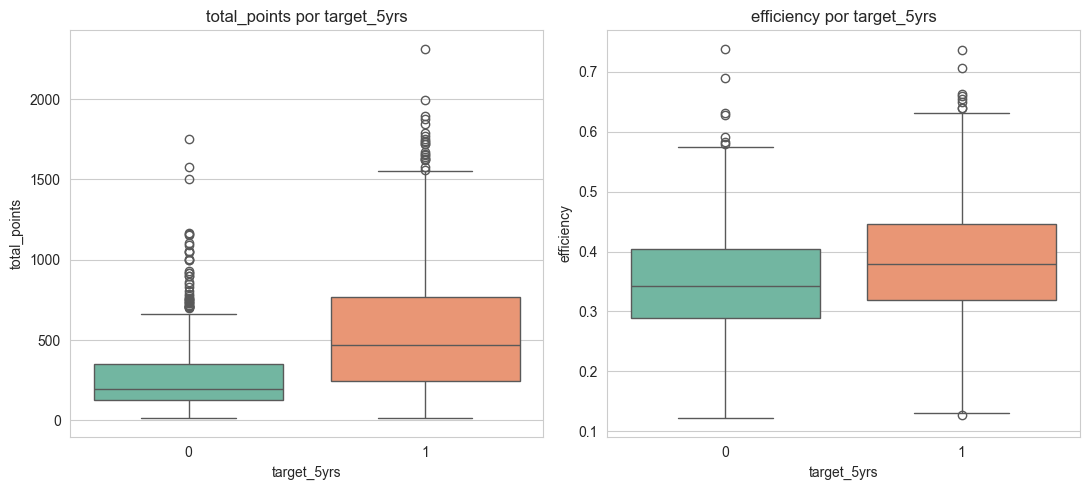

In [18]:
# Comparar `total_points` y `efficiency` entre las dos clases objetivo.

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sns.boxplot(data=extracted_data, x="target_5yrs", y="total_points", palette="Set2", ax=axes[0])
axes[0].set_title("total_points por target_5yrs")

sns.boxplot(data=extracted_data, x="target_5yrs", y="efficiency", palette="Set2", ax=axes[1])
axes[1].set_title("efficiency por target_5yrs")

plt.tight_layout()
plt.show()

**Observación:** en ambos casos la mediana de la clase 1 (5+ años) está claramente por encima de la clase 0, lo que confirma visualmente que estas dos features extraídas son buenas candidatas para predecir el objetivo.

Naive Bayes asume que las features son independientes entre sí dado la clase. Como `total_points` y `efficiency` ya incorporan la información de `gp`, `pts` y `min`, esas tres columnas originales se eliminan para evitar redundancia.

In [19]:
# Eliminar las columnas que ya fueron usadas para extraer las nuevas features.

extracted_data = extracted_data.drop(columns=["gp", "pts", "min"])

extracted_data.head()

,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304


### Resumen del proceso *(extra)*

In [20]:
# Resumen de cuántas columnas quedaron en cada etapa.

resumen = pd.DataFrame({
    "Etapa": ["Datos originales", "Después de selección", "Después de extracción (final)"],
    "N° columnas": [data.shape[1], selected_data.shape[1], extracted_data.shape[1]],
})
resumen

,Etapa,N° columnas
0,Datos originales,21
1,Después de selección,12
2,Después de extracción (final),11


In [21]:
# Exportar los datos finales, listos para el modelado con Naive Bayes.

extracted_data.to_csv("extracted_nba_players_data.csv", index=0)

## Consideraciones — Parte 1

- Verificar el balance de clases es clave: si una clase superara ~90%, convendría re-balancear los datos (sobre/submuestreo) antes de modelar.
- La selección de características no es solo intuición: la matriz de correlación la respalda con datos.
- La extracción de características (`total_points`, `efficiency`) creó variables más informativas que las columnas originales que las componen, y las visualizaciones lo confirman.
- Este dataset queda listo (`extracted_nba_players_data.csv`) para la Parte 2: construir el modelo de Naive Bayes.


---
# PARTE 2 · Construir un modelo de Naive Bayes
---

## Teoría: el teorema de Bayes y el supuesto "naive" *(contenido extra)*

El **teorema de Bayes** permite calcular la probabilidad de una clase $y$ dado un conjunto de features $X$:

$$P(y \mid X) = \frac{P(X \mid y)\, P(y)}{P(X)}$$

Calcular $P(X \mid y)$ directamente es difícil cuando hay muchas features, porque requeriría modelar todas sus interacciones. El supuesto **"naive" (ingenuo)** simplifica esto asumiendo que las features son **condicionalmente independientes entre sí, dada la clase**:

$$P(X \mid y) = \prod_{i=1}^{n} P(x_i \mid y)$$

Aunque este supuesto casi nunca se cumple exactamente en datos reales, en la práctica el modelo suele funcionar bien de todos modos, y es muy rápido de entrenar.

**Variantes según el tipo de dato de las features:**

| Variante | Supone que las features son... | Caso de uso típico |
|---|---|---|
| `GaussianNB` | Continuas, con distribución normal | Mediciones numéricas continuas (nuestro caso) |
| `MultinomialNB` | Conteos discretos (≥ 0) | Conteo de palabras en texto |
| `BernoulliNB` | Binarias (0/1) | Presencia/ausencia de una característica |
| `CategoricalNB` | Categóricas discretas | Variables categóricas codificadas |

Como nuestras features (`fg`, `3p`, `ft`, `reb`, `total_points`, `efficiency`, etc.) son numéricas continuas, `GaussianNB` es la elección natural — y más abajo la comparamos contra `BernoulliNB` para mostrar en la práctica por qué esa elección importa.


## Paso 1: Importaciones

In [22]:
# Importar librerías y módulos relevantes.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import naive_bayes
from sklearn import model_selection
from sklearn import metrics

Cargamos `extracted_nba_players_data.csv`, el resultado de la Parte 1 (ingeniería de características).

In [23]:
# Cargar los datos ya trabajados en la Parte 1.

extracted_data = pd.read_csv('extracted_nba_players_data.csv')

extracted_data.head(10)

,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304
5,42.3,32.5,73.2,0.8,1.8,0.4,0.0,0.7,0,277.5,0.324561
6,43.5,50.0,81.1,2.0,0.6,0.2,0.1,0.7,1,409.2,0.605505
7,41.5,30.0,87.5,1.7,0.2,0.2,0.1,0.7,1,273.6,0.553398
8,39.2,23.3,71.4,0.8,2.3,0.3,0.0,1.1,0,156.0,0.242424
9,38.3,21.4,67.8,1.1,0.3,0.2,0.0,0.7,0,155.4,0.435294


## Paso 2: Preparación del modelo

### Aislar variables objetivo y predictoras

In [24]:
# Variable objetivo (y).

y = extracted_data['target_5yrs']

# Variables predictoras (X).

X = extracted_data.drop('target_5yrs', axis=1)

In [25]:
y.head(10)

0    0
1    0
2    0
3    1
4    1
5    0
6    1
7    1
8    0
9    0
Name: target_5yrs, dtype: int64

**Observación:** la variable objetivo es binaria (0/1), lo que exige un modelo apto para clasificación binaria.

In [26]:
X.head(10)

,fg,3p,ft,reb,ast,stl,blk,tov,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,216.0,0.391304
5,42.3,32.5,73.2,0.8,1.8,0.4,0.0,0.7,277.5,0.324561
6,43.5,50.0,81.1,2.0,0.6,0.2,0.1,0.7,409.2,0.605505
7,41.5,30.0,87.5,1.7,0.2,0.2,0.1,0.7,273.6,0.553398
8,39.2,23.3,71.4,0.8,2.3,0.3,0.0,1.1,156.0,0.242424
9,38.3,21.4,67.8,1.1,0.3,0.2,0.0,0.7,155.4,0.435294


**Observación:** todas las variables predictoras son numéricas continuas.

### División train/test

In [27]:
# División 75% entrenamiento / 25% prueba.

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, random_state=0)

In [28]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1005, 10)
(335, 10)
(1005,)
(335,)


## Paso 3: Construcción del modelo

**¿Qué algoritmo usar?** Como las features son continuas y asumimos que siguen aproximadamente una distribución normal, `GaussianNB` es el más apropiado.

In [29]:
# Ajustar GaussianNB a los datos de entrenamiento y predecir sobre los datos de prueba.

nb = naive_bayes.GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

### Comparación de variantes de Naive Bayes *(contenido extra)*

Para ilustrar por qué el supuesto de cada variante importa, entrenamos también un `BernoulliNB`, que espera features **binarias**. Para poder usarlo, binarizamos cada columna respecto a su mediana (calculada solo con datos de entrenamiento, para no filtrar información del set de prueba).

In [30]:
# Binarizar las features respecto a la mediana del set de entrenamiento.

medianas = X_train.median()
X_train_bin = (X_train > medianas).astype(int)
X_test_bin = (X_test > medianas).astype(int)

nb_bernoulli = naive_bayes.BernoulliNB()
nb_bernoulli.fit(X_train_bin, y_train)
y_pred_bernoulli = nb_bernoulli.predict(X_test_bin)

## Paso 4: Resultados y evaluación

### Métricas — GaussianNB

In [31]:
print('accuracy score:', metrics.accuracy_score(y_test, y_pred))
print('precision score:', metrics.precision_score(y_test, y_pred))
print('recall score:', metrics.recall_score(y_test, y_pred))
print('f1 score:', metrics.f1_score(y_test, y_pred))

accuracy score: 0.6895522388059702
precision score: 0.8405797101449275
recall score: 0.5858585858585859
f1 score: 0.6904761904761905


**Observaciones:**

- La **precisión (accuracy)** ronda 0.69: el modelo acierta ~69% de las veces en general.
- La **precision** (0.84) es alta: cuando el modelo predice que un jugador durará 5+ años, suele acertar.
- El **recall** (0.59) es más bajo: al modelo le cuesta más identificar correctamente a los jugadores que **no** durarán 5 años.
- El **f1 score** (0.69) resume el balance entre precision y recall.

La accuracy sola no alcanza para evaluar el modelo, sobre todo con clases algo desbalanceadas: conviene mirar precision, recall y f1 en conjunto.

### Matriz de confusión — GaussianNB

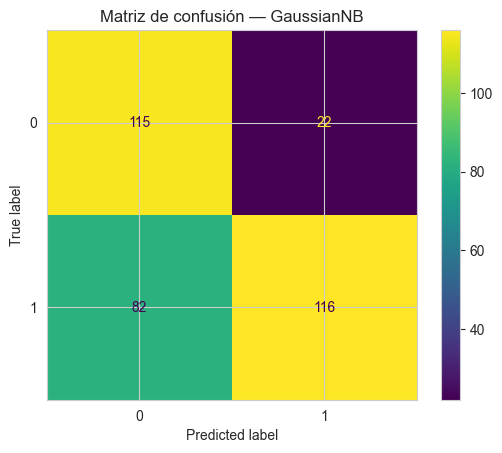

In [32]:
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)
disp.plot()
plt.title("Matriz de confusión — GaussianNB")
plt.show()

### Curva ROC *(visualización extra)*

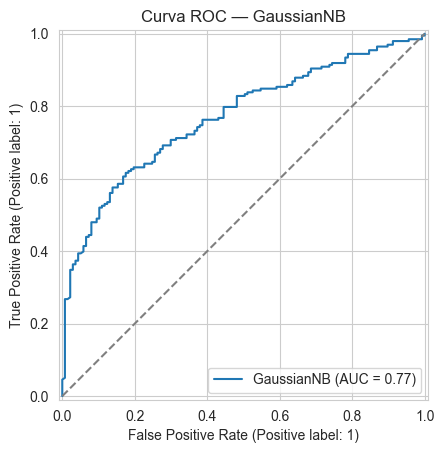

In [33]:
# Curva ROC y AUC para GaussianNB.

metrics.RocCurveDisplay.from_estimator(nb, X_test, y_test)
plt.title("Curva ROC — GaussianNB")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.show()

Un AUC cercano a 1 indica que el modelo separa bien ambas clases en todos los umbrales posibles; un AUC de 0.5 equivaldría a predecir al azar.

### GaussianNB vs. BernoulliNB *(comparación extra)*

In [34]:
# Tabla comparativa de métricas entre ambas variantes.

comparacion = pd.DataFrame({
    "GaussianNB": [
        metrics.accuracy_score(y_test, y_pred),
        metrics.precision_score(y_test, y_pred),
        metrics.recall_score(y_test, y_pred),
        metrics.f1_score(y_test, y_pred),
    ],
    "BernoulliNB": [
        metrics.accuracy_score(y_test, y_pred_bernoulli),
        metrics.precision_score(y_test, y_pred_bernoulli),
        metrics.recall_score(y_test, y_pred_bernoulli),
        metrics.f1_score(y_test, y_pred_bernoulli),
    ],
}, index=["accuracy", "precision", "recall", "f1"])

comparacion

,GaussianNB,BernoulliNB
accuracy,0.689552,0.698507
precision,0.840580,0.741294
recall,0.585859,0.752525
f1,0.690476,0.746867


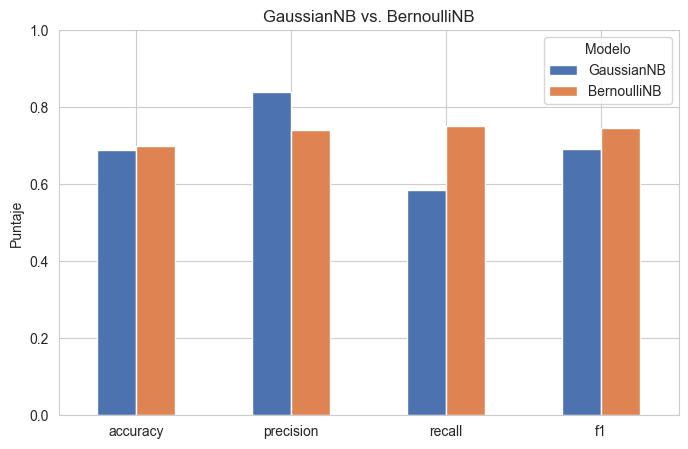

In [35]:
# Gráfico de barras comparando ambas variantes.

comparacion.plot(kind="bar", figsize=(8, 5), color=["#4C72B0", "#DD8452"])
plt.title("GaussianNB vs. BernoulliNB")
plt.ylabel("Puntaje")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.show()

**Observación:** se espera que `GaussianNB` iguale o supere a `BernoulliNB` en la mayoría de las métricas, porque nuestras features son continuas y la binarización (convertirlas a 0/1 según la mediana) descarta información al perder la magnitud de cada valor — solo queda si está por encima o por debajo del promedio. Esto ilustra en la práctica por qué elegir la variante de Naive Bayes adecuada al tipo de dato importa tanto como la ingeniería de características en sí.

## Consideraciones — Parte 2

- La evaluación del modelo importa tanto como construirlo: accuracy sola puede ser engañosa.
- Dividir en train/test es necesario para medir qué tan bien generaliza el modelo a datos nuevos.
- Precision, recall, f1 y la matriz de confusión dan una foto más completa del rendimiento que una sola métrica.
- Elegir la variante de Naive Bayes correcta según el tipo de dato de las features (continuo → Gaussian, binario → Bernoulli, etc.) afecta directamente el rendimiento.


## Cierre general

Este notebook mostró el flujo completo de un proyecto de ML aplicado a datos de la NBA:

1. **Ingeniería de características**: de 21 columnas originales, seleccionamos 12, y luego extrajimos 2 nuevas features (`total_points`, `efficiency`) que resultaron ser buenas predictoras, quedando 11 columnas finales.
2. **Naive Bayes**: entrenamos `GaussianNB` sobre esas features, lo evaluamos con múltiples métricas y lo comparamos contra `BernoulliNB` para mostrar el impacto de elegir bien la variante del algoritmo.

**Para la práctica de mañana**, esto permite mostrar no solo *cómo* se hace cada paso, sino *por qué* se toma cada decisión (selección de columnas respaldada por correlación, elección de algoritmo respaldada por el tipo de dato, evaluación respaldada por múltiples métricas en vez de una sola).